# LangGraph — Zero to Hero  |  Day 1: The Absolute Basics

**Goal of Day 1:** understand *what* LangGraph is and build your first working graphs — **no LLM, no API key, no cost.**

> Why no LLM today? An LLM is just *one kind* of step inside a graph. If you first understand the graph machinery
> (state, nodes, edges), everything in Days 2–10 (agents, tools, memory, multi-agent) becomes easy.


### What you will learn today
| # | Topic | You will be able to... |
|---|-------|------------------------|
| 0 | Setup | Install LangGraph and verify it works |
| 1 | Hello World | Build & run your first graph |
| 2 | Multiple nodes | Chain steps that share data |
| 3 | Reducers | Control *how* state gets updated |
| 4 | Conditional edges | Make decisions / branching |
| 5 | Loops | Repeat steps (the superpower of LangGraph) |
| 6 | Streaming | Watch your graph run step by step |
| 7 | Mini project | Support-ticket triage workflow |
| 8 | Cheat sheet + Exercises | Practice with solutions |


**Prerequisites:** basic Python (functions, dicts, `if/else`). Nothing else.

**How to use this notebook:** run cells top-to-bottom with `Shift + Enter`. Read the text, run the code, then *change something and re-run*.

## Part 0 — The Big Idea

**LangGraph** is a Python library for building workflows as a **graph** — think *flowchart that can actually run*.


Imagine a **board game**:

* 🧾 **State** = the *score sheet* everybody can read and write on.
* 🟦 **Node** = a *square on the board*. When you land on it, you do some work and update the score sheet.
* ➡️ **Edge** = an *arrow* telling you which square comes next.
* 🔀 **Conditional edge** = an arrow with a *rule*: "if you rolled > 3, go left, otherwise go right".

|

 Concept | In code | Plain English |
|---|---|---|
| **State** | a `TypedDict` | The shared data that flows through the graph |
| **Node** | a normal Python function `f(state) -> dict` | One unit of work |
| **Edge** | `add_edge(a, b)` | "After `a`, run `b`" |
| **Conditional edge** | `add_conditional_edges(a, router)` | "After `a`, let `router` pick what's next" |
| **START / END** | special markers | Where the graph begins and finishes |
| **compile()** | `builder.compile()` | Turns your blueprint into a runnable app |



### Why not just write normal Python functions?
You *can* — until you need **loops, branching, retries, human approval, saving progress, or multiple agents**.
LangGraph gives you all of those in a clean, visual, debuggable structure. That is why it is the go-to framework for **AI agents**.


### The 5-step recipe (you'll repeat this all course long)
```
1. Define the State          →  class State(TypedDict): ...
2. Write the Nodes           →  def my_node(state): return {...}
3. Create builder, add nodes →  StateGraph(State).add_node(...)
4. Connect with edges        →  add_edge / add_conditional_edges
5. compile() and invoke()    →  app = builder.compile(); app.invoke({...})
```

## ⚙️ Part 1 — Setup

Install LangGraph (run once). Use Python **3.10+**.

> If you use Google Colab or Jupyter, the `%pip` magic below works as-is. In a terminal use `pip install -U langgraph`.

In [1]:
%pip install -q -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 11.5 MB/s eta 0:00:00


In [2]:
# Verify the installation
import sys
from importlib.metadata import version

print("Python    :", sys.version.split()[0])
print("LangGraph :", version("langgraph"))

Python    : 3.13.15
LangGraph : 1.2.12


## Part 2 — Hello World: your first graph

We'll build the smallest possible graph:

```
START ──► greet ──► END
```

**Step 1 – State.** The shared "score sheet". We use `TypedDict` to declare which keys exist.<br>
**Step 2 – Node.** A plain function. It *receives* the whole state and *returns only the keys it wants to change*.<br>
**Step 3/4 – Builder + edges.** Register the node, connect `START → greet → END`.<br>
**Step 5 – compile + invoke.** Run it with an input dict.

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


In [6]:
# Step 1: State -------------------------------------------------
class State(TypedDict):
    name: str
    greeting: str

In [5]:
# Step 2: Node --------------------------------------------------
def greet(state: State) -> dict:
    # read from state, return ONLY what you want to update
    return {"greeting": f"Hello, {state['name']}! Welcome to LangGraph 👋"}

In [7]:
# Step 3 + 4: Builder, nodes, edges -----------------------------
builder = StateGraph(State)
builder.add_node("greet", greet)        # (name, function)
builder.add_edge(START, "greet")
builder.add_edge("greet", END)

In [8]:

# Step 5: Compile and run ---------------------------------------
app = builder.compile()
result = app.invoke({"name": "Asha"})
print(result)

{'name': 'Asha', 'greeting': 'Hello, Asha! Welcome to LangGraph 👋'}


In [10]:
assert result["greeting"].startswith("Hello, Asha")
print("Hello World works!")

Hello World works!


### What just happened?
1. `invoke({"name": "Asha"})` created the **initial state** → `{"name": "Asha"}`.
2. The graph followed `START → greet`. LangGraph called `greet(state)`.
3. `greet` returned `{"greeting": "..."}`. LangGraph **merged** that into the state.
4. The graph followed `greet → END` and returned the **final state**.

> **Golden rule:** nodes return *updates* (partial dicts), not the full state. LangGraph does the merging.



In [ ]:
### Visualize your graph
# `get_graph().draw_mermaid()` returns diagram text. Paste it into <https://mermaid.live> to see the picture.

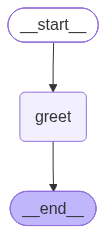

In [15]:
app

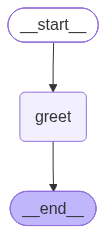

In [16]:
# Optional: render the picture directly inside Jupyter (needs internet access).
# Safe to skip - the cell never breaks the notebook if it fails.
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Skipped image rendering (needs internet / IPython):", type(e).__name__)

## Part 3 — Multiple nodes sharing state

Real workflows have several steps. Each node reads what earlier nodes wrote.

```
START ──► clean ──► count_words ──► label_length ──► END
```

In [17]:
class TextState(TypedDict):
    raw_text: str
    clean_text: str
    word_count: int
    label: str



In [18]:
def clean(state: TextState) -> dict:
    # collapse extra spaces and lower-case
    return {"clean_text": " ".join(state["raw_text"].split()).lower()}

In [19]:
def count_words(state: TextState) -> dict:
    return {"word_count": len(state["clean_text"].split())}

In [20]:
def label_length(state: TextState) -> dict:
    return {"label": "short" if state["word_count"] < 5 else "long"}

In [22]:
b = StateGraph(TextState)
b.add_node("clean", clean)
b.add_node("count_words", count_words)
b.add_node("label_length", label_length)

In [23]:
b.add_edge(START, "clean")
b.add_edge("clean", "count_words")
b.add_edge("count_words", "label_length")
b.add_edge("label_length", END)

In [24]:
text_app = b.compile()


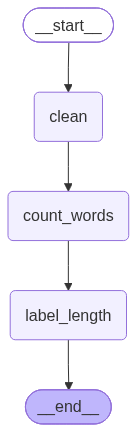

In [97]:
text_app

In [25]:
out = text_app.invoke({"raw_text": "   Hello     LangGraph   World  "})
print(out)



{'raw_text': '   Hello     LangGraph   World  ', 'clean_text': 'hello langgraph world', 'word_count': 3, 'label': 'short'}


In [28]:
assert out["clean_text"] == "hello langgraph world"
assert out["word_count"] == 3
assert out["label"] == "short"
print("Multi-node pipeline works!")

Multi-node pipeline works!


### Try it yourself
Change `raw_text` to a longer sentence (5+ words) and re-run. The label should become `"long"`.

> **Default behaviour = overwrite.** If two nodes write the same key, the *last one wins*.
> That's fine for single values like `word_count`. But what about a **list that should grow**? → Reducers

## Part 4 — Reducers: *how* state is updated

By default, a returned value **replaces** the old one. A **reducer** changes that rule.
You attach one using `Annotated[type, reducer_function]`.

The most common reducer is `operator.add` — for lists it means **append / concatenate**.

Let's run the *same two nodes* with and without a reducer and compare.

In [29]:
import operator
from typing import Annotated

In [30]:
# --- Version 1: NO reducer (overwrite) ---
class OverwriteState(TypedDict):
    log: list[str]

In [31]:
# --- Version 2: WITH reducer (append) ---
class AppendState(TypedDict):
    log: Annotated[list[str], operator.add]     # <- the magic line

In [32]:
def build_app(StateType):
    def step_a(state):
        return {"log": ["step A ran"]}
    def step_b(state):
        return {"log": ["step B ran"]}

    g = StateGraph(StateType)
    g.add_node("step_a", step_a)
    g.add_node("step_b", step_b)
    g.add_edge(START, "step_a")
    g.add_edge("step_a", "step_b")
    g.add_edge("step_b", END)
    return g.compile()

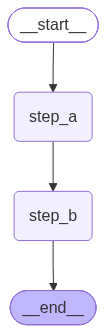

In [98]:
build_app(OverwriteState)

In [33]:
print("Without reducer:", build_app(OverwriteState).invoke({"log": []}))
print("With reducer   :", build_app(AppendState).invoke({"log": []}))



Without reducer: {'log': ['step B ran']}
With reducer   : {'log': ['step A ran', 'step B ran']}


In [34]:
assert build_app(OverwriteState).invoke({"log": []})["log"] == ["step B ran"]
assert build_app(AppendState).invoke({"log": []})["log"] == ["step A ran", "step B ran"]
print("✅ Reducers understood!")

✅ Reducers understood!


### Key takeaways
* **No reducer** → new value **overwrites** old value (`['step B ran']`).
* **With `operator.add`** → new list is **added** to old list (`['step A ran', 'step B ran']`).
* In **Day 2** you'll meet the built-in `add_messages` reducer — the same idea, used to keep chat history.
* You can write your own reducer: any function `f(old_value, new_value) -> merged_value`.

In [36]:
# Bonus: a custom reducer - keep the MAXIMUM score seen so far
def keep_max(old: int, new: int) -> int:
    return max(old, new)


In [37]:
class ScoreState(TypedDict):
    best: Annotated[int, keep_max]


In [38]:

def judge_1(state): return {"best": 7}
def judge_2(state): return {"best": 4}   # lower score, should NOT replace 7



In [39]:
g = StateGraph(ScoreState)
g.add_node("judge_1", judge_1)
g.add_node("judge_2", judge_2)
g.add_edge(START, "judge_1")
g.add_edge("judge_1", "judge_2")
g.add_edge("judge_2", END)



{'best': 7}


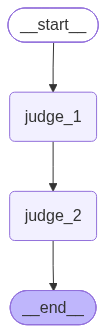

In [99]:
g.compile()

In [ ]:
res = g.compile().invoke({"best": 0})
print(res)

In [40]:
assert res["best"] == 7
print("✅ Custom reducer works!")

✅ Custom reducer works!


## Part 5 — Conditional edges (branching)

A **conditional edge** lets the graph *decide* where to go next, based on the current state.

You provide a **router function**: it reads the state and returns the **name of the next node**.

```
                      ┌──► billing_team ──┐
START ──► classify ───┼──► tech_team ─────┼──► END
                      └──► general_team ──┘
```

In [41]:
from typing import Literal

class TicketState(TypedDict):
    message: str
    category: str
    reply: str

In [42]:

def classify(state: TicketState) -> dict:
    text = state["message"].lower()
    if "refund" in text or "charge" in text:
        category = "billing"
    elif "error" in text or "crash" in text:
        category = "technical"
    else:
        category = "general"
    return {"category": category}

In [43]:

# ROUTER: returns the NAME of the next node (not a state update!)
def route_ticket(state: TicketState) -> Literal["billing_team", "tech_team", "general_team"]:
    return {
        "billing":   "billing_team",
        "technical": "tech_team",
        "general":   "general_team",
    }[state["category"]]

In [44]:
def billing_team(state: TicketState) -> dict:
    return {"reply": "💳 Billing team: we are checking your payment."}

In [45]:
def tech_team(state: TicketState) -> dict:
    return {"reply": "🛠️ Tech team: please share the error log."}

In [46]:
def general_team(state: TicketState) -> dict:
    return {"reply": "💬 Support: thanks for reaching out!"}

In [47]:
b = StateGraph(TicketState)


In [48]:
b.add_node("classify", classify)


In [49]:
b.add_node("billing_team", billing_team)


In [50]:
b.add_node("tech_team", tech_team)


In [51]:
b.add_node("general_team", general_team)

In [52]:
b.add_edge(START, "classify")


In [53]:
b.add_conditional_edges("classify", route_ticket)      # <- the decision point


In [54]:
b.add_edge("billing_team", END)


In [55]:
b.add_edge("tech_team", END)

In [56]:
b.add_edge("general_team", END)

In [57]:
ticket_app = b.compile()

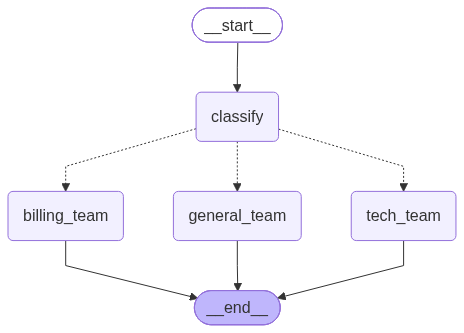

In [101]:
ticket_app

In [58]:
tests = {
    "I want a refund for a double charge": "billing",
    "The app shows an error and crashes":  "technical",
    "What are your opening hours?":        "general",
}

In [60]:
for msg, expected in tests.items():
    r = ticket_app.invoke({"message": msg})
    print(f"{msg!r}\n   -> {r['category']:9s} | {r['reply']}")
    assert r["category"] == expected
print("\n Conditional routing works!")

'I want a refund for a double charge'
   -> billing   | 💳 Billing team: we are checking your payment.
'The app shows an error and crashes'
   -> technical | 🛠️ Tech team: please share the error log.
'What are your opening hours?'
   -> general   | 💬 Support: thanks for reaching out!

 Conditional routing works!


### 📝 Two ways to write a router
1. **Return node names directly** (what we did above). Add a `Literal[...]` return type so diagrams show all branches.
2. **Return a label + give a mapping** — useful when labels differ from node names:

```python
builder.add_conditional_edges(
    "classify",
    route_function,                 # returns e.g. "yes" or "no"
    {"yes": "node_a", "no": END},   # label -> next node
)
```
We use style 2 in the next part.

## Part 6 — Loops (cycles)

This is where LangGraph beats simple chains: **a conditional edge can point *back* to an earlier node**, creating a loop.
Agents use this to *"think → act → check → think again..."* until done.

```
START ──► increment ──► (count < limit?) ──yes──┐
              ▲                                  │
              └──────────────────────────────────┘
                              │ no
                              ▼
                             END
```

In [61]:
class CounterState(TypedDict):
    count: int
    limit: int
    history: Annotated[list[int], operator.add]

In [62]:
def increment(state: CounterState) -> dict:
    new_count = state["count"] + 1
    return {"count": new_count, "history": [new_count]}

In [63]:
def should_continue(state: CounterState) -> str:
    return "again" if state["count"] < state["limit"] else "stop"

In [64]:
b = StateGraph(CounterState)


In [65]:
b.add_node("increment", increment)


In [66]:
b.add_edge(START, "increment")


In [67]:
b.add_conditional_edges("increment", should_continue, {"again": "increment", "stop": END})

In [68]:
loop_app = b.compile()

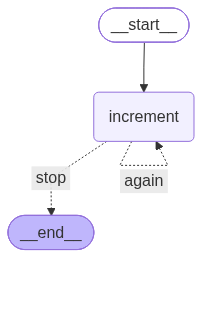

In [102]:
loop_app

In [69]:
res = loop_app.invoke({"count": 0, "limit": 3, "history": []})
print(res)

{'count': 3, 'limit': 3, 'history': [1, 2, 3]}


In [70]:
assert res["count"] == 3
assert res["history"] == [1, 2, 3]
print("✅ Loop works!")

✅ Loop works!


### Safety net: the recursion limit
What if your loop **never** ends? LangGraph stops it after a maximum number of steps (default **25**) and raises `GraphRecursionError`.
You can set your own limit through `config`. Let's trigger it on purpose:

In [71]:
from langgraph.errors import GraphRecursionError

try:
    # limit=100 but we only allow 5 steps -> the safety net kicks in
    loop_app.invoke({"count": 0, "limit": 100, "history": []},
                    config={"recursion_limit": 5})
except GraphRecursionError:
    print("🛑 Caught GraphRecursionError - the runaway loop was stopped safely.")
else:
    raise AssertionError("Expected GraphRecursionError")

🛑 Caught GraphRecursionError - the runaway loop was stopped safely.


## Part 7 — Streaming: watch the graph think

`invoke()` gives only the final answer. `stream()` yields results **as each step finishes** — great for debugging and live UIs.

| `stream_mode` | You receive |
|---|---|
| `"updates"` | Only what **each node returned**: `{node_name: update}` |
| `"values"` | The **full state** after every step |

In [72]:
print("=== stream_mode='updates' (what each node changed) ===")
for chunk in text_app.stream({"raw_text": "  LangGraph   makes agents   easy "}, stream_mode="updates"):
    print(chunk)

print("\n=== stream_mode='values' (full state after each step) ===")


=== stream_mode='updates' (what each node changed) ===
{'clean': {'clean_text': 'langgraph makes agents easy'}}
{'count_words': {'word_count': 4}}
{'label_length': {'label': 'short'}}

=== stream_mode='values' (full state after each step) ===


In [73]:
snapshots = []
for state in text_app.stream({"raw_text": "  LangGraph   makes agents   easy "}, stream_mode="values"):
    snapshots.append(state)
    print(state)

assert snapshots[-1]["word_count"] == 4
print("\n✅ Streaming works!")

{'raw_text': '  LangGraph   makes agents   easy '}
{'raw_text': '  LangGraph   makes agents   easy ', 'clean_text': 'langgraph makes agents easy'}
{'raw_text': '  LangGraph   makes agents   easy ', 'clean_text': 'langgraph makes agents easy', 'word_count': 4}
{'raw_text': '  LangGraph   makes agents   easy ', 'clean_text': 'langgraph makes agents easy', 'word_count': 4, 'label': 'short'}

✅ Streaming works!


## Part 8 — Mini project: Support-ticket triage

Let's combine **everything** from today: state, reducer, conditional edges, and a final step.

```
START ► classify ► set_priority ► (route) ┬► billing_team ─┐
                                          ├► tech_team ────┼► finalize ► END
                                          └► general_team ─┘
```

* `log` uses a **reducer** so every node can add an audit trail.
* `set_priority` marks urgent tickets as `high`.
* `finalize` assembles the final response.

In [74]:
class TriageState(TypedDict):
    message: str
    category: str
    priority: str
    reply: str
    log: Annotated[list[str], operator.add]

In [75]:
def t_classify(state: TriageState) -> dict:
    text = state["message"].lower()
    if any(w in text for w in ("refund", "charge", "invoice")):
        cat = "billing"
    elif any(w in text for w in ("error", "crash", "bug")):
        cat = "technical"
    else:
        cat = "general"
    return {"category": cat, "log": [f"classified as {cat}"]}

In [76]:
def t_priority(state: TriageState) -> dict:
    urgent = any(w in state["message"].lower() for w in ("urgent", "asap", "immediately"))
    pr = "high" if urgent else "normal"
    return {"priority": pr, "log": [f"priority = {pr}"]}


In [77]:
def t_route(state: TriageState) -> Literal["t_billing", "t_tech", "t_general"]:
    return {"billing": "t_billing", "technical": "t_tech", "general": "t_general"}[state["category"]]


In [79]:
def t_billing(state: TriageState) -> dict:
    return {"reply": "Billing team will review your payment.", "log": ["handled by billing"]}

In [80]:
def t_tech(state: TriageState) -> dict:
    return {"reply": "Tech team will investigate the issue.", "log": ["handled by tech"]}

In [81]:
def t_general(state: TriageState) -> dict:
    return {"reply": "Our support team will get back to you.", "log": ["handled by general"]}

In [82]:
def t_finalize(state: TriageState) -> dict:
    prefix = "🚨 [HIGH PRIORITY] " if state["priority"] == "high" else ""
    return {"reply": prefix + state["reply"], "log": ["finalized"]}

In [83]:
b = StateGraph(TriageState)

In [84]:
for name, fn in [("t_classify", t_classify), ("t_priority", t_priority),
                 ("t_billing", t_billing), ("t_tech", t_tech),
                 ("t_general", t_general), ("t_finalize", t_finalize)]:
    b.add_node(name, fn)

In [85]:
b.add_edge(START, "t_classify")

In [86]:
b.add_edge("t_classify", "t_priority")

In [87]:
b.add_conditional_edges("t_priority", t_route)

In [88]:
b.add_edge("t_billing", "t_finalize")

In [89]:
b.add_edge("t_tech", "t_finalize")


In [91]:
b.add_edge("t_general", "t_finalize")


In [92]:
b.add_edge("t_finalize", END)

In [93]:
triage_app = b.compile()

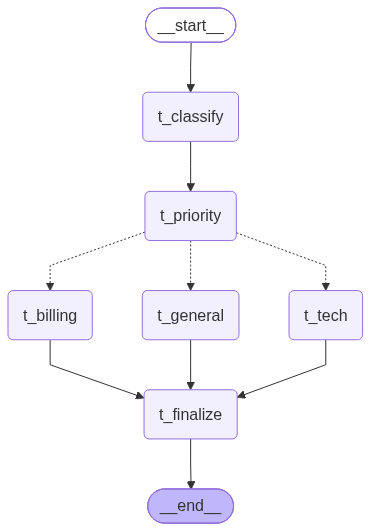

In [103]:
triage_app

In [94]:
r = triage_app.invoke({"message": "URGENT: the app crashes with an error on login!", "log": []})
for k, v in r.items():
    print(f"{k:9s}: {v}")

message  : URGENT: the app crashes with an error on login!
category : technical
priority : high
reply    : 🚨 [HIGH PRIORITY] Tech team will investigate the issue.
log      : ['classified as technical', 'priority = high', 'handled by tech', 'finalized']


In [95]:
assert r["category"] == "technical"
assert r["priority"] == "high"
assert r["reply"].startswith("🚨")
assert r["log"] == ["classified as technical", "priority = high", "handled by tech", "finalized"]

In [96]:
r2 = triage_app.invoke({"message": "Please send my invoice", "log": []})
assert r2["category"] == "billing" and r2["priority"] == "normal"
print("\n✅ Mini project works!")


✅ Mini project works!


## Part 9 — Cheat sheet & common mistakes

```python
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    x: int
    items: Annotated[list, operator.add]       # reducer = append

def node(state: State) -> dict:                # returns PARTIAL update
    return {"x": state["x"] + 1}

g = StateGraph(State)
g.add_node("node", node)
g.add_edge(START, "node")
g.add_conditional_edges("node", router, {"a": "node", "b": END})
g.add_edge("node", END)
app = g.compile()

app.invoke({"x": 0})                           # final state
app.stream({"x": 0}, stream_mode="updates")    # step by step
app.get_graph().draw_mermaid()                 # diagram text
```

### Common beginner mistakes
| Mistake | Fix |
|---|---|
| Forgetting `compile()` | Always `app = builder.compile()` before `invoke` |
| Node returns the whole state or `None` | Return a **dict of updates** |
| Router returns a name that doesn't exist | Names must match `add_node` names (or END) |
| Lists get overwritten | Add a reducer: `Annotated[list, operator.add]` |
| Infinite loop | Make sure the loop condition can become false; use `recursion_limit` |
| No edge into the graph | Every graph needs an edge from `START` |
| Reusing a node name | Node names must be unique |

## Part 10 — Exercises (with solutions)

Try each exercise **in a new cell first**, then compare with the solution below it.

**Exercise 1 – Extend the pipeline.** Add a node `uppercase` between `clean` and `count_words` that stores an upper-case copy in a new key `shout`.

**Exercise 2 – Branching.** Build a graph that receives `{"number": int}` and routes to `even_node` or `odd_node`, each setting `result` to `"even"` / `"odd"`.

**Exercise 3 – Looping.** Build a countdown: start with `{"n": 3}`, loop decreasing `n` by 1 until it reaches 0, collecting every value in `seen` (using a reducer). Expected `seen == [2, 1, 0]`.

#### ✅ Solution 1

In [104]:
class ShoutState(TypedDict):
    raw_text: str
    clean_text: str
    shout: str
    word_count: int

def s_clean(state: ShoutState) -> dict:
    return {"clean_text": " ".join(state["raw_text"].split()).lower()}

def uppercase(state: ShoutState) -> dict:
    return {"shout": state["clean_text"].upper()}

def s_count(state: ShoutState) -> dict:
    return {"word_count": len(state["clean_text"].split())}



In [105]:
g = StateGraph(ShoutState)
g.add_node("clean", s_clean)
g.add_node("uppercase", uppercase)
g.add_node("count_words", s_count)
g.add_edge(START, "clean")
g.add_edge("clean", "uppercase")
g.add_edge("uppercase", "count_words")
g.add_edge("count_words", END)



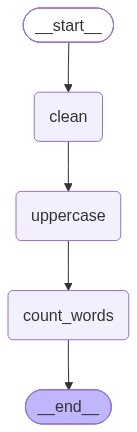

In [106]:
g.compile()

In [ ]:
out = g.compile().invoke({"raw_text": "  hi   there "})
print(out)
assert out["shout"] == "HI THERE" and out["word_count"] == 2
print("✅ Solution 1 OK")

#### ✅ Solution 2

In [107]:
class NumState(TypedDict):
    number: int
    result: str

def even_node(state: NumState) -> dict:
    return {"result": "even"}

def odd_node(state: NumState) -> dict:
    return {"result": "odd"}

def parity_router(state: NumState) -> Literal["even_node", "odd_node"]:
    return "even_node" if state["number"] % 2 == 0 else "odd_node"



In [108]:
g = StateGraph(NumState)
g.add_node("even_node", even_node)
g.add_node("odd_node", odd_node)
g.add_conditional_edges(START, parity_router)      # routers can start at START too!
g.add_edge("even_node", END)
g.add_edge("odd_node", END)




In [109]:
parity_app = g.compile()

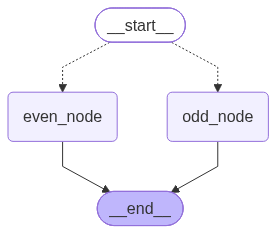

In [110]:
parity_app

In [ ]:
assert parity_app.invoke({"number": 4})["result"] == "even"
assert parity_app.invoke({"number": 7})["result"] == "odd"
print("✅ Solution 2 OK")

#### ✅ Solution 3

In [111]:
class CountdownState(TypedDict):
    n: int
    seen: Annotated[list[int], operator.add]

def tick(state: CountdownState) -> dict:
    new_n = state["n"] - 1
    return {"n": new_n, "seen": [new_n]}

def keep_going(state: CountdownState) -> str:
    return "again" if state["n"] > 0 else "done"



In [112]:
g = StateGraph(CountdownState)
g.add_node("tick", tick)
g.add_edge(START, "tick")
g.add_conditional_edges("tick", keep_going, {"again": "tick", "done": END})



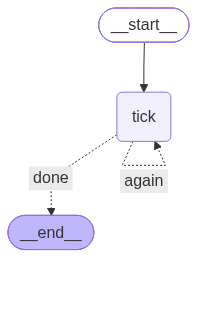

In [114]:
g.compile()

In [115]:
res = g.compile().invoke({"n": 3, "seen": []})
print(res)
assert res["seen"] == [2, 1, 0] and res["n"] == 0
print("✅ Solution 3 OK")

{'n': 0, 'seen': [2, 1, 0]}
✅ Solution 3 OK


## Day 1 Summary

You can now:
- ✅ Explain **State, Nodes, Edges, START/END** and `compile()`
- ✅ Build linear graphs with several nodes
- ✅ Use **reducers** (`operator.add`, custom) to merge state
- ✅ Branch with **conditional edges**
- ✅ Build **loops** and protect them with `recursion_limit`
- ✅ **Stream** execution and **visualize** graphs
- ✅ Combine everything into a real mini workflow